# Hungarian primal-dual iterates

This notebook generates `fig:matching-hungarian-progression`.  The toy problem is a diagonally dominant ordered one-dimensional squared-distance assignment, whose optimum is the identity permutation.  The displayed matrices are actual augmentation states: unassigned rows remain flat, assigned rows are one-hot, and the final panel is the identity assignment.


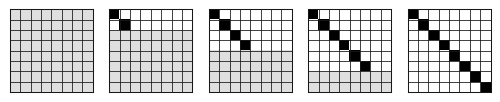

In [1]:
from pathlib import Path
import sys

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        NOTEBOOK_DIR = candidate.resolve()
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np

from figure_style import figure_dir, save_pdf, setup_matplotlib

setup_matplotlib()


def draw_matrix(ax, M):
    n = M.shape[0]
    ax.imshow(M, cmap="gray_r", vmin=0, vmax=1, interpolation="nearest")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax.grid(which="minor", color="#181818", linewidth=0.58)
    ax.tick_params(which="minor", bottom=False, left=False)
    for spine in ax.spines.values():
        spine.set_linewidth(0.75)
        spine.set_color("#181818")


def render_assignment_state(row_match):
    """Display the current matching: flat unassigned rows, one-hot assigned rows."""
    n = len(row_match)
    M = np.full((n, n), 1.0 / n)
    for i, j in enumerate(row_match):
        if j >= 0:
            M[i, :] = 0.0
            M[i, j] = 1.0
    return M


def hungarian_snapshots(C):
    n = C.shape[0]
    u = C.min(axis=1).copy()
    v = np.zeros(n)
    row_match = -np.ones(n, dtype=int)
    col_match = -np.ones(n, dtype=int)
    snapshots = []

    def snapshot(stage):
        snapshots.append((stage, render_assignment_state(row_match.copy())))

    snapshot(0)
    for root in range(n):
        if row_match[root] != -1:
            continue
        S = np.zeros(n, dtype=bool)
        T = np.zeros(n, dtype=bool)
        slack = np.full(n, np.inf)
        slack_row = -np.ones(n, dtype=int)
        S[root] = True
        slack[:] = C[root] - u[root] - v
        slack_row[:] = root
        while True:
            candidates = np.where(~T)[0]
            j = candidates[np.argmin(slack[candidates])]
            delta = slack[j]
            u[S] += delta
            v[T] -= delta
            slack[~T] -= delta
            T[j] = True
            i = col_match[j]
            if i == -1:
                while True:
                    i0 = slack_row[j]
                    next_j = row_match[i0]
                    row_match[i0] = j
                    col_match[j] = i0
                    if next_j == -1:
                        break
                    j = next_j
                snapshot(int(np.sum(row_match >= 0)))
                break
            S[i] = True
            for jj in np.where(~T)[0]:
                val = C[i, jj] - u[i] - v[jj]
                if val < slack[jj] - 1e-14:
                    slack[jj] = val
                    slack_row[jj] = i
    if not np.all(row_match == np.arange(n)):
        raise RuntimeError(f"Hungarian did not recover identity assignment: {row_match}")
    return snapshots


def save_stage_panels(stages, out, thumb):
    for k, (_, M) in enumerate(stages):
        fig, ax = plt.subplots(figsize=(1.05, 1.05))
        draw_matrix(ax, M)
        save_pdf(fig, out / f"stage-{k}.pdf", pad_inches=0.012)
        plt.close(fig)
    fig, axs = plt.subplots(1, len(stages), figsize=(6.2, 1.25))
    for ax, (_, M) in zip(axs, stages):
        draw_matrix(ax, M)
    fig.savefig(thumb, dpi=230, bbox_inches="tight", pad_inches=0.02)
    plt.show()


OUT = figure_dir("matching-hungarian-progression")
THUMB = NOTEBOOK_DIR / "thumbnails" / "matching-hungarian-progression.png"
THUMB.parent.mkdir(exist_ok=True)

n = 8
x = np.linspace(-1.0, 1.0, n)
# Mild target-grid perturbations keep the identity optimum while avoiding
# misleading off-diagonal intermediate states in this pedagogical display.
y = x + np.array([-0.030, 0.015, -0.018, 0.010, -0.010, 0.018, -0.015, 0.030])
C = (x[:, None] - y[None, :]) ** 2
all_snapshots = hungarian_snapshots(C)
selected_indices = [0, 2, 4, 6, 8]
stages = [all_snapshots[k] for k in selected_indices]

# The selected pedagogical instance should display diagonal partial identities.
for stage, M in stages:
    expected = render_assignment_state(np.r_[np.arange(stage), -np.ones(n - stage, dtype=int)])
    np.testing.assert_allclose(M, expected)

save_stage_panels(stages, OUT, THUMB)
